# Subgraph Centrality

### Imports

In [1]:
from __future__ import annotations
import networkx as nx
import numpy as np
import pytest
from scipy.special import factorial
from abc import ABC, abstractmethod

### Error Classes

In [2]:
class NormalizationError(Exception):
    """Exception raised for errors in the normalization.

    Attributes:
        message -- explanation of the error
    """

    def __init__(self, message="An error occurred during normalization."):
        self.message = message
        super().__init__(self.message)

class NullGraphError(Exception):
    """Exception raised for null graph."""
    pass

class EmptyGraphError(Exception):
    """Exception raised for empty graph. Nodes with no edges."""
    pass


def check_raw_value(func):
    """Decorator to check if raw value is None. If it is, raise an error."""
    def wrapper(self, *args):
        if self._raw_value is not None:
            return func(self, *args)
        else:
            raise ValueError("Raw value is None. Call compute() method first.")
    return wrapper

### Abstract Class

In [3]:
class _Property(ABC):
    """Abstract base class for all properties."""
    _return_type = None
    _use_paths = False
    _use_direction = False
    _use_selfloops = False
    _use_giant_component = False

    def __init__(self, G: nx.DiGraph):
        self.G = G
        self._raw_value = None
        self._n_nodes = self.G.number_of_nodes()
        if self._n_nodes == 0:
            raise NullGraphError("Can not calculate subgraph centrality for inexistent nodes.")

    @abstractmethod
    def compute(self):
        return self._raw_value

    @abstractmethod
    def norm_biol(self, *args):
        pass

    @abstractmethod
    def norm_network(self, *args):
        pass

### Decorators 

In [4]:
def use_direction(cls):
    cls._use_direction = True
    return cls

def use_selfloops(cls):
    cls._use_selfloops = True
    return cls

def use_giant_component(cls):
    cls._use_giant_component = True
    return cls

def return_scalar(cls):
    cls._return_type = "scalar"
    return cls

def return_distribution(cls):
    cls._return_type = "distribution"
    return cls

def use_paths(cls):
    cls._use_paths = True
    return cls

### Subgraph Centrality Class

Fórmula con la spectral decomposition of the adjacency matrix.

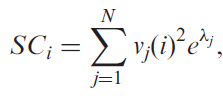

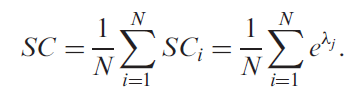

***Subgraph centrality*** is a centrality measure that is defined as a measurement that characterizes nodes based on the number of
closed walks through the network starting and ending on each node. Closed walks have different weights,
this means not every one has the same influence. The centrality decreases as the length of closed walks increases.
It is a valuable measurement because it is capable of differentiating nodes even when other centrality measurements could not. And also 
when every node in the network has the same subgraph centrality, they also share the DC, CC, BC and EC (Degree Centrality, Closeness Centrality, Betweenness Centrality and Eigenvector Centrality respectively).[16089598]

In [5]:
@return_distribution
@use_selfloops   
class Subgraph_Centrality(_Property): # Hereda de la clase _Property
    """Subgraph centrality.

    Subgraph centrality is defined as the "sum" of closed walks of different lengths throught the network
    starting and ending in each node.

    Methods:
        compute: Compute the subgraph centrality for every node in the graph.
        norm_biol: NO IMPLEMENTATION.
        norm_network: Normalize subgraph centrality for every node to the max theoretical value.
    """
    __name__ = 'Subgraph Centrality'
    
    def __init__(self, G: nx.DiGraph):
        """
        Args:
            G (nx.DiGraph): Graph.
        """
        super().__init__(G)

    def compute(self) -> np.array:
        """Compute the subgraph centrality for every node in the graph.

        Returns:
            nparray: subgraph centrality for every node.  
        """
        n_edges = self.G.number_of_edges()
        if n_edges == 0:
            raise EmptyGraphError("There are no edges. Can not calculate subgraph centrality of nodes that do not form any edges.")
        
        self._raw_value = nx.subgraph_centrality(self.G.to_undirected())
        self._raw_value = np.fromiter(self._raw_value.values(), dtype=float)
        
        return self._raw_value

    @check_raw_value    # Decorator to check if raw value is None. If it is, raise an error.
    def norm_biol(self):
        raise NormalizationError("No biological normalization implemented.")

    @check_raw_value
    def norm_network(self):
        """Normalize the subgraph centrality of the graph to the max value, obtained from a complete graph of the same size"""
        
        T = nx.DiGraph()
        n_nodes= self._n_nodes
        T.add_nodes_from(range(n_nodes))
        T.add_edges_from([(i, j) for i in range(n_nodes) for j in range(n_nodes)])
        
        max = Subgraph_Centrality(T)

        return self._raw_value / max.compute()

### Testing

In [6]:
# Null graph
G = nx.DiGraph()
with pytest.raises(NullGraphError) as e_info:
    property = Subgraph_Centrality(G)

# Empty graph, allows instance from an empty graph, but does not compute
n_nodes= 6
G.add_nodes_from(range(n_nodes))
property = Subgraph_Centrality(G)
with pytest.raises(EmptyGraphError) as e_info:
    property.compute()

# add edges
# complete directed graph with self loops
G.add_edges_from([(i, j) for i in range(n_nodes) for j in range(n_nodes)])
property = Subgraph_Centrality(G)

expected = np.array([68.071, 68.071, 68.071, 68.071, 68.071, 68.071])
expected_1 = np.array([1,1,1,1,1,1])

assert np.allclose(property.compute(), expected)
assert np.allclose(property.norm_network(), expected_1)
with pytest.raises(NormalizationError) as e_info:
    property.norm_biol()

# add edges
# only half of the nodes are parents and regulate every node in the graph
G = nx.DiGraph()
n_nodes= 6
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i, j) for i in range(n_nodes//2) for j in range(n_nodes)])
property = Subgraph_Centrality(G)

expected = np.array([31.61901, 31.61901, 31.61901, 12.52167, 12.52167, 12.52167])
expected_1 = np.array([0.4644973,  0.4644973,  0.4644973,  0.18394889, 0.18394889, 0.18394889])

assert np.allclose(property.compute(), expected)
assert np.allclose(property.norm_network(), expected_1)
with pytest.raises(NormalizationError) as e_info:
    property.norm_biol()


In [7]:
# add edges
# complete directed graph with self loops
G = nx.DiGraph()
n_nodes= 7
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i, j) for i in range(n_nodes) for j in range(n_nodes)])
property = Subgraph_Centrality(G)
print(f'\t\t>>> Complete Graph\n\tRaw value = {property.compute()}\n\tNetwork Norm = {property.norm_network()}\n')

# add edges
# only half of the nodes are parents and regulate every node in the graph
G = nx.DiGraph()
n_nodes= 6
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i, j) for i in range(n_nodes//2) for j in range(n_nodes)])
property = Subgraph_Centrality(G)
print(f'\t\t>>> 2 Parents Fully Connected\n\tRaw value = {property.compute()}\n\tNetwork Norm = {property.norm_network()}\n\n')

		>>> Complete Graph
	Raw value = [157.51902263 157.51902263 157.51902263 157.51902263 157.51902263
 157.51902263 157.51902263]
	Network Norm = [1. 1. 1. 1. 1. 1. 1.]

		>>> 2 Parents Fully Connected
	Raw value = [31.61901164 31.61901164 31.61901164 12.52167045 12.52167045 12.52167045]
	Network Norm = [0.4644973  0.4644973  0.4644973  0.18394889 0.18394889 0.18394889]




### Fórmula con momentos espectrales locales

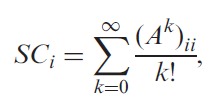

In [8]:
G = nx.DiGraph()
n_nodes = 6
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i, j) for i in range(n_nodes) for j in range(n_nodes)])

A = nx.adjacency_matrix(G)
A = A.toarray()

ks = np.arange(n_nodes + 1)
ks = factorial(ks)

pre_sc = np.zeros((n_nodes, n_nodes + 1))

for k in range(1, n_nodes + 1):
    a = np.linalg.matrix_power(A, k)
    pre_sc[..., k] = a.diagonal()

pre_sc = pre_sc / ks
nodes_sc = pre_sc.sum(axis=1)

nodes_sc

C:\Users\PepeS\AppData\Local\Temp\ipykernel_22332\2234385971.py:6: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  A = nx.adjacency_matrix(G)


array([40.6, 40.6, 40.6, 40.6, 40.6, 40.6])